In [1]:
!pip install -q diffusers[training]==0.36.0 transformers accelerate peft bitsandbytes datasets

import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 13.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.25 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
onnx 1.20.1 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.3 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20

Add the cityscapes dataset, florence2 generated captions, and the stable diffusion dataset (i put it as a dataset on kaggle because pulling it from the hugging face repository during script execution was very slow, maybe due to kaggle server limitations idk) as input for this kaggle notebook

Check if the stable diffusion dataset has the right files

In [2]:
import os

print("=== All inputs ===")
for item in os.listdir("/kaggle/input/"):
    print(f"  {item}")

# # Check SD 1.5 model structure
# print("\n=== SD 1.5 model files ===")
# sd_path = None
# for root, dirs, files in os.walk("/kaggle/input/"):
#     for f in files:
#         if f == "model_index.json":
#             sd_path = root
#             break
#     if sd_path:
#         break

# if sd_path:
#     print(f"Model root: {sd_path}")
#     for f in ["unet/diffusion_pytorch_model.safetensors", 
#               "text_encoder/model.safetensors",
#               "vae/diffusion_pytorch_model.safetensors",
#               "model_index.json"]:
#         full = os.path.join(sd_path, f)
#         if os.path.exists(full):
#             size = os.path.getsize(full) / 1e6
#             print(f"  ✓ {size:8.0f} MB  {f}")
#         else:
#             print(f"  ✗ MISSING     {f}")
# else:
#     print("model_index.json not found — check dataset structure")

=== All inputs ===
  datasets


Check if the florence captions dataset and cityscapes dataset have the right files

In [3]:
import os

print("=== Available input datasets ===")
for item in os.listdir("/kaggle/input/datasets/narmeensabahsiddiqui"):
    print(f"  {item}")

# Check the captions dataset structure
captions_path = "/kaggle/input/datasets/narmeensabahsiddiqui/florence2-detailedcaptions-cityscapes"
print("=== Captions dataset ===")
for item in os.listdir(captions_path):
    print(f"  {item}")

# Check the images dataset structure
images_path = "/kaggle/input/datasets/narmeensabahsiddiqui/cityscapes-leftimg8bit-traintestval"
print("\n=== Images dataset ===")
for item in os.listdir(images_path):
    print(f"  {item}")
    subpath = os.path.join(images_path, item)
    if os.path.isdir(subpath):
        for sub in os.listdir(subpath)[:5]:
            print(f"    {sub}")

=== Available input datasets ===
  florence2-detailedcaptions-cityscapes
  cityscapes-leftimg8bit-traintestval
=== Captions dataset ===
  metadata.jsonl
  captions.json
  __huggingface_repos__.json

=== Images dataset ===
  leftImg8bit
    val
    test
    train
  README
  license.txt


Assembling the dataset to be used by the hugging face's prebuilt train_text_to_image_lora training script

In [4]:
import os
import json
import shutil

IMAGES_ROOT = "/kaggle/input/datasets/narmeensabahsiddiqui/cityscapes-leftimg8bit-traintestval/leftImg8bit"
CAPTIONS_FILE = "/kaggle/input/datasets/narmeensabahsiddiqui/florence2-detailedcaptions-cityscapes/metadata.jsonl"
TRAIN_DIR = "/kaggle/working/lora165000_dataset"

# Create the training directory
os.makedirs(TRAIN_DIR, exist_ok=True)

# Symlink the train folder so images are accessible at lora_dataset/train/city/image.png
try:
    os.symlink(os.path.join(IMAGES_ROOT, "train"), os.path.join(TRAIN_DIR, "train"))
    os.symlink(os.path.join(IMAGES_ROOT, "test"), os.path.join(TRAIN_DIR, "test"))
    os.symlink(os.path.join(IMAGES_ROOT, "val"), os.path.join(TRAIN_DIR, "val"))
except:
    print("Symlink did not work")
    pass
# Copy metadata.jsonl into the training directory
shutil.copy(CAPTIONS_FILE, os.path.join(TRAIN_DIR, "metadata.jsonl"))

# Verify: check that a few image paths from metadata.jsonl actually resolve
with open(os.path.join(TRAIN_DIR, "metadata.jsonl"), "r") as f:
    first_entry = json.loads(f.readline())

test_path = os.path.join(TRAIN_DIR, first_entry["file_name"])
print(f"First entry file_name: {first_entry['file_name']}")
print(f"Full resolved path:    {test_path}")
print(f"File exists: {os.path.exists(test_path)}")
print(f"Caption: {first_entry['text'][:100]}...")

# Count total entries
with open(os.path.join(TRAIN_DIR, "metadata.jsonl"), "r") as f:
    total = sum(1 for _ in f)
print(f"\nTotal image-caption pairs: {total}")

First entry file_name: train/aachen/aachen_000000_000019_leftImg8bit.png
Full resolved path:    /kaggle/working/lora165000_dataset/train/aachen/aachen_000000_000019_leftImg8bit.png
File exists: True
Caption: A car driving down a street lined with tall buildings, trees, light poles, and sign boards. The sky ...

Total image-caption pairs: 5000


Download the training script "train_text_to_image_lora.py" from diffusers library on hugging face's github

In [5]:
# Download the training script that matches our installed diffusers version (0.36.0)
import os
if not os.path.exists('/kaggle/working/train_text_to_image_lora.py'):
    !wget -q https://raw.githubusercontent.com/huggingface/diffusers/v0.36.0/examples/text_to_image/train_text_to_image_lora.py -O /kaggle/working/train_text_to_image_lora.py
    print("Script downloaded")
    print(f"Script exists: {os.path.exists('/kaggle/working/train_text_to_image_lora.py')}")
else:
    print("Script exists")

# Verify it doesn't have the version check issue
!head -70 /kaggle/working/train_text_to_image_lora.py | grep "check_min_version"

Script downloaded
Script exists: True
    check_min_version,
check_min_version("0.36.0")


patch the code to convert all the trainable params to float32. This is a limitation of the new version of accelerate library that is present on this kaggle environment

In [6]:
with open("/kaggle/working/train_text_to_image_lora.py", "r") as f:
    lines = f.readlines()

with open("/kaggle/working/train_text_to_image_lora.py", "w") as f:
    for line in lines:
        f.write(line)
        if "unet.add_adapter(unet_lora_config)" in line:
            f.write("    # Fix: cast LoRA params to float32 for mixed precision training\n")
            f.write("    for param in unet.parameters():\n")
            f.write("        if param.requires_grad:\n")
            f.write("            param.data = param.data.to(torch.float32)\n")

# Verify
with open("/kaggle/working/train_text_to_image_lora.py", "r") as f:
    content = f.read()
print("Patched:" if "param.data.to(torch.float32)" in content else "PATCH FAILED")

Patched:


In [7]:
# SD_MODEL_PATH = "/kaggle/input/datasets/narmeensabahsiddiqui/sd15-diffusers"

!accelerate launch --multi_gpu --num_processes=2 --mixed_precision="fp16" \
  /kaggle/working/train_text_to_image_lora.py \
  --pretrained_model_name_or_path="stable-diffusion-v1-5/stable-diffusion-v1-5" \
  --train_data_dir="/kaggle/working/lora165000_dataset" \
  --caption_column="text" \
  --resolution=512 \
  --center_crop \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --max_train_steps=5000 \
  --learning_rate=1e-4 \
  --max_grad_norm=1.0 \
  --lr_scheduler="cosine" \
  --lr_warmup_steps=200 \
  --snr_gamma=5.0 \
  --rank=16 \
  --output_dir="/kaggle/working/cityscapes-lora165000" \
  --checkpointing_steps=400 \
  --seed=42 \
  --logging_dir="/kaggle/working/logs-165000" \
  --report_to="tensorboard"

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_machines` was set to a value of `1`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
INFO:__main__:Distributed environment: DistributedType.MULTI_GPU  Backend: nccl
Num processes: 2
Process index: 1
Lo

In [8]:
# Check the output files
import os

print("=== Output files ===")
for root, dirs, files in os.walk("/kaggle/working/cityscapes-lora165000"):
    for f in files:
        full = os.path.join(root, f)
        size = os.path.getsize(full) / 1e6
        rel = os.path.relpath(full, "/kaggle/working/cityscapes-lora165000")
        print(f"  {size:8.2f} MB  {rel}")

=== Output files ===
     12.79 MB  pytorch_lora_weights.safetensors
      0.00 MB  checkpoint-4800/scaler.pt
     25.72 MB  checkpoint-4800/optimizer.bin
      0.02 MB  checkpoint-4800/random_states_0.pkl
      0.00 MB  checkpoint-4800/scheduler.bin
     12.79 MB  checkpoint-4800/pytorch_lora_weights.safetensors
      0.00 MB  checkpoint-1600/scaler.pt
     25.72 MB  checkpoint-1600/optimizer.bin
      0.02 MB  checkpoint-1600/random_states_0.pkl
      0.00 MB  checkpoint-1600/scheduler.bin
     12.79 MB  checkpoint-1600/pytorch_lora_weights.safetensors
      0.00 MB  checkpoint-4000/scaler.pt
     25.72 MB  checkpoint-4000/optimizer.bin
      0.02 MB  checkpoint-4000/random_states_0.pkl
      0.00 MB  checkpoint-4000/scheduler.bin
     12.79 MB  checkpoint-4000/pytorch_lora_weights.safetensors
      0.00 MB  checkpoint-2000/scaler.pt
     25.72 MB  checkpoint-2000/optimizer.bin
      0.02 MB  checkpoint-2000/random_states_0.pkl
      0.00 MB  checkpoint-2000/scheduler.bin
     12.79 

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or audit

...

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/30 [00:00<?, ?it/s]

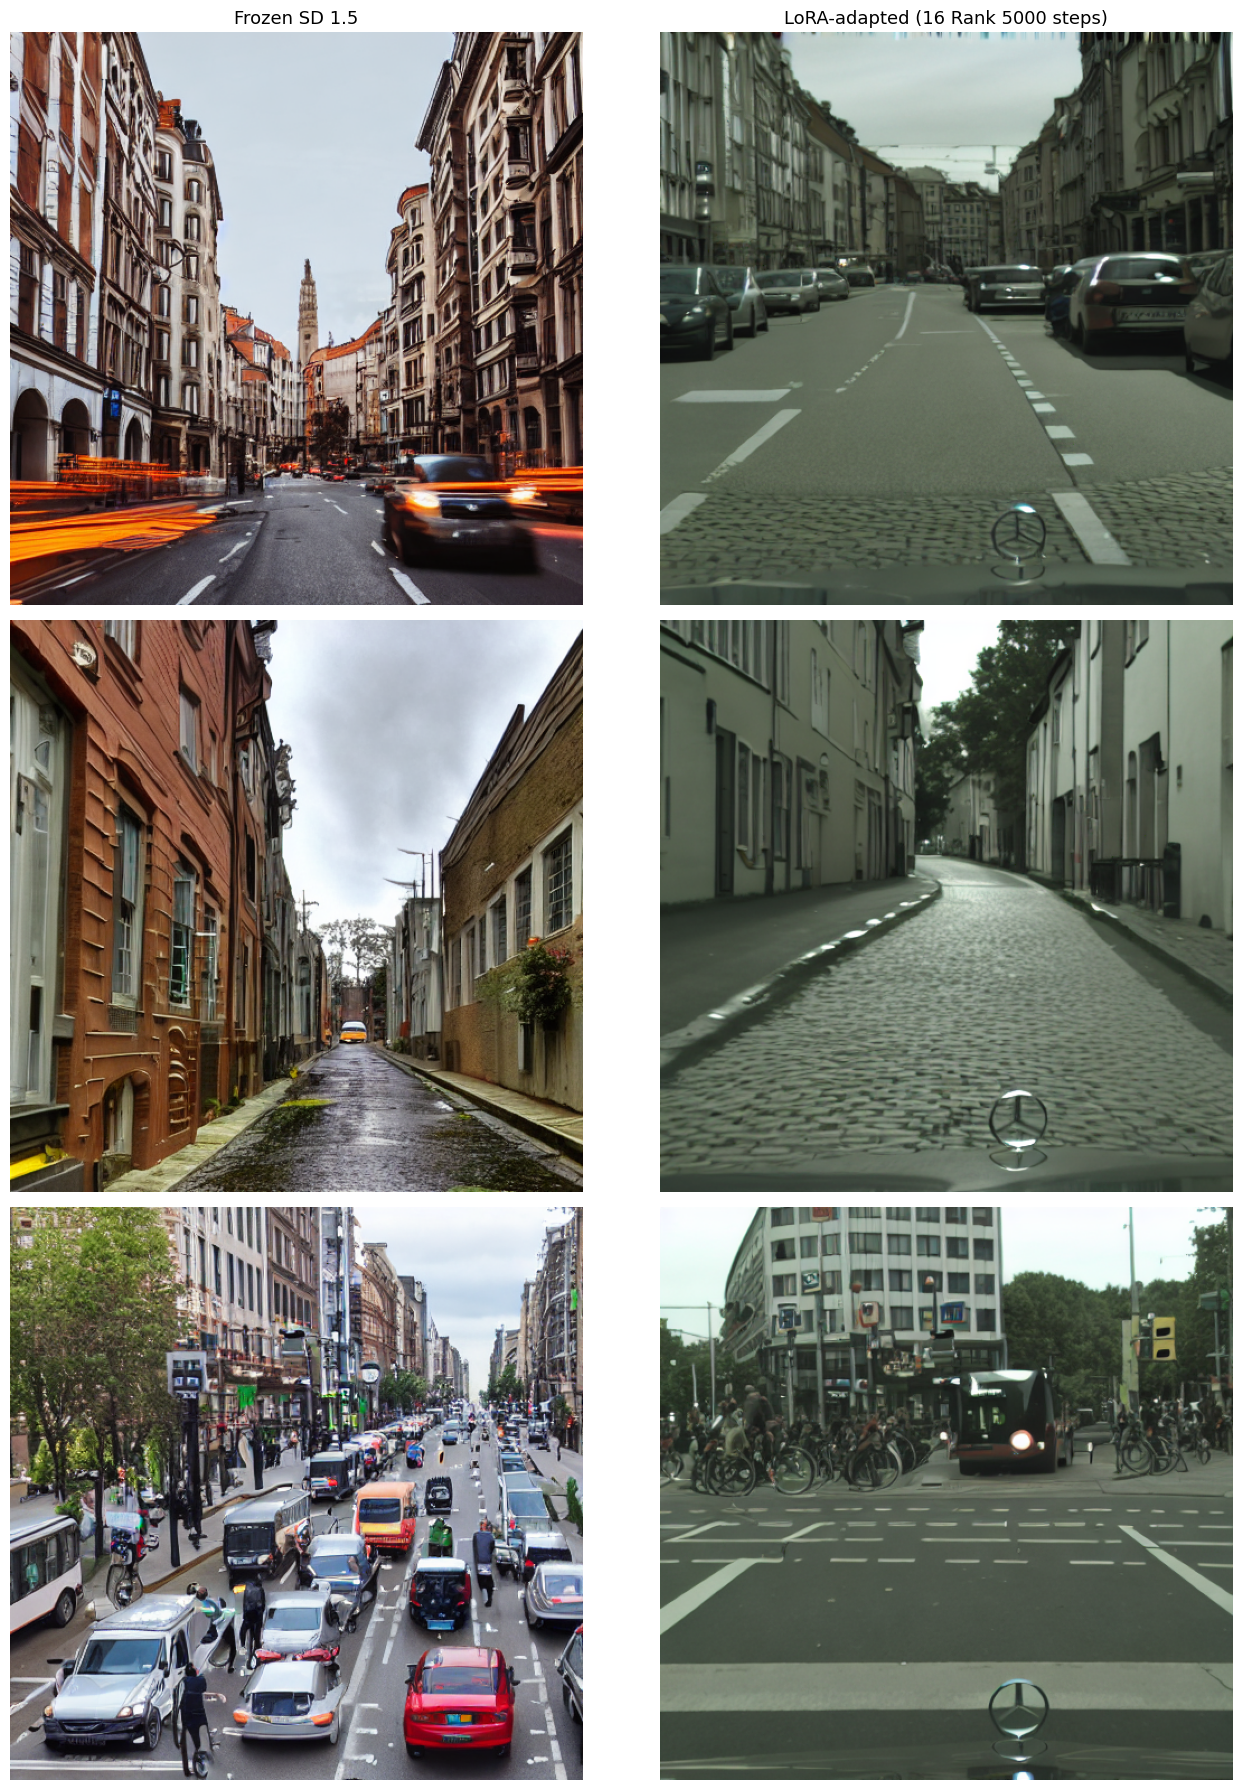

In [9]:
# from diffusers import StableDiffusionPipeline
# import torch

# SD_PATH = "/kaggle/input/datasets/narmeensabahsiddiqui/sd15-diffusers"
# LORA_PATH = "/kaggle/working/cityscapes-lora-pilot"

# prompt = "A dashcam view of a European city street with cars, buildings, and pedestrians"

# # Load without safety checker (which needs the missing feature_extractor)
# pipe = StableDiffusionPipeline.from_pretrained(
#     SD_PATH, 
#     torch_dtype=torch.float16,
#     safety_checker=None,
#     feature_extractor=None
# ).to("cuda")

# # Generate with frozen SD 1.5
# generator = torch.Generator("cuda").manual_seed(42)
# img_frozen = pipe(prompt, generator=generator, num_inference_steps=30).images[0]

# # Load LoRA weights and generate again
# pipe.load_lora_weights(LORA_PATH)
# generator = torch.Generator("cuda").manual_seed(42)
# img_lora = pipe(prompt, generator=generator, num_inference_steps=30).images[0]

# # Display side by side
# import matplotlib.pyplot as plt
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# axes[0].imshow(img_frozen)
# axes[0].set_title("Frozen SD 1.5", fontsize=13)
# axes[0].axis("off")
# axes[1].imshow(img_lora)
# axes[1].set_title("LoRA-adapted SD 1.5 (200 steps)", fontsize=13)
# axes[1].axis("off")
# plt.suptitle(f'Prompt: "{prompt}"', fontsize=11, y=0.02)
# plt.tight_layout()
# plt.show()
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt

# SD_PATH = "/kaggle/input/datasets/narmeensabahsiddiqui/sd15-diffusers"
LORA_PATH = "/kaggle/working/cityscapes-lora165000" #changed from  "/kaggle/working/cityscapes-lora-pilot"

prompts = [
    "A dashcam view of a European city street with cars, buildings, and pedestrians",
    "A narrow street with parked cars and trees on both sides under overcast sky",
    "A busy intersection with traffic lights, buses, and cyclists in a city",
]

# Load pipeline without safety checker
pipe = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=torch.float16,
    safety_checker=None, feature_extractor=None
).to("cuda")

fig, axes = plt.subplots(len(prompts), 2, figsize=(14, 6 * len(prompts)))

for i, prompt in enumerate(prompts):
    # Frozen SD 1.5
    pipe.unload_lora_weights()
    generator = torch.Generator("cuda").manual_seed(42 + i)
    img_frozen = pipe(prompt, generator=generator, num_inference_steps=30).images[0]
    
    # LoRA-adapted
    pipe.load_lora_weights(LORA_PATH)
    generator = torch.Generator("cuda").manual_seed(42 + i)
    img_lora = pipe(prompt, generator=generator, num_inference_steps=30).images[0]
    
    axes[i, 0].imshow(img_frozen)
    axes[i, 0].set_title("Frozen SD 1.5" if i == 0 else "", fontsize=13)
    axes[i, 0].set_ylabel(prompt[:50] + "...", fontsize=9, rotation=0, labelpad=120, va='center')
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(img_lora)
    axes[i, 1].set_title("LoRA-adapted (16 Rank 5000 steps)" if i == 0 else "", fontsize=13)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()